# MIPT Tutorial - Measurement-Induced Phase Transition

This tutorial demonstrates the **Measurement-Induced Phase Transition (MIPT)** in a 1D quantum circuit with random unitary gates and projective measurements.

## What is MIPT?

The MIPT arises from a competition between two processes:

1. **Unitary evolution** (Haar random gates): Creates entanglement between qubits
2. **Projective measurements** (Z-basis): Destroys entanglement locally

Depending on the measurement rate, the system exhibits two distinct phases:

- **Volume-law phase** (p < p_c ≈ 0.16): Entanglement entropy scales with system size S ~ L
- **Area-law phase** (p > p_c ≈ 0.16): Entanglement entropy remains constant S ~ const
- **Critical point** (p ≈ p_c): Logarithmic scaling S ~ log(L)


## Setup

First, activate the project environment and import QuantumCircuitsMPS:

In [ ]:
using Pkg; Pkg.activate(dirname(@__DIR__))
using QuantumCircuitsMPS
using Printf
using Statistics
using Plots
using ProgressMeter
using Luxor

## Section 1: Setup and Parameters

Define the system parameters for the MIPT simulation:

In [2]:
# Define system parameters
const L = 8                   # System size (number of qubits)
const bc = :periodic           # Boundary conditions
const n_steps = L             # Total timesteps for simulation (passed to simulate!(n_steps=n_steps))
const p = 0.5                 # Measurement probability (near critical p_c ≈ 0.16)
const cut = L ÷ 2              # Entanglement cut position

println("Parameters:")
println("  L = $L (system size)")
println("  bc = $bc (boundary conditions)")
println("  n_steps = $n_steps (circuit timesteps)")
println("  p = $p (measurement probability)")
println("  cut = $cut (entanglement cut position)")

Parameters:
  L = 8 (system size)
  bc = periodic (boundary conditions)
  n_steps = 8 (circuit timesteps)
  p = 0.5 (measurement probability)
  cut = 4 (entanglement cut position)
  L = 8 (system size)
  bc = periodic (boundary conditions)
  n_steps = 8 (circuit timesteps)
  p = 0.5 (measurement probability)
  cut = 4 (entanglement cut position)


## Section 2: Building the MIPT Circuit

The circuit implements the standard MIPT protocol with Bricklayer unitary gates followed by stochastic measurements.


In [3]:
# Build circuit (one full MIPT cycle per do-block execution: even+measure+odd+measure)
circuit = Circuit(L=L, bc=bc, p=p) do c
    apply!(c, HaarRandom(), Bricklayer(:even))
    apply_with_prob!(c; outcomes=[
        (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
    ])
    apply!(c, HaarRandom(), Bricklayer(:odd))
    apply_with_prob!(c; outcomes=[
        (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
    ])
end

println("Circuit built successfully")
println("Circuit parameters: L=$(circuit.L), bc=$(circuit.bc)")
println("System size: $(circuit.L) qubits")
println("Boundary conditions: $(circuit.bc)")

Circuit built successfully
Circuit parameters: L=8, bc=periodic
System size: 8 qubits
Boundary conditions: periodic
Circuit parameters: L=8, bc=periodic
System size: 8 qubits
Boundary conditions: periodic


### Circuit Visualization

Visualize the circuit structure to inspect the gate layout before running the simulation:

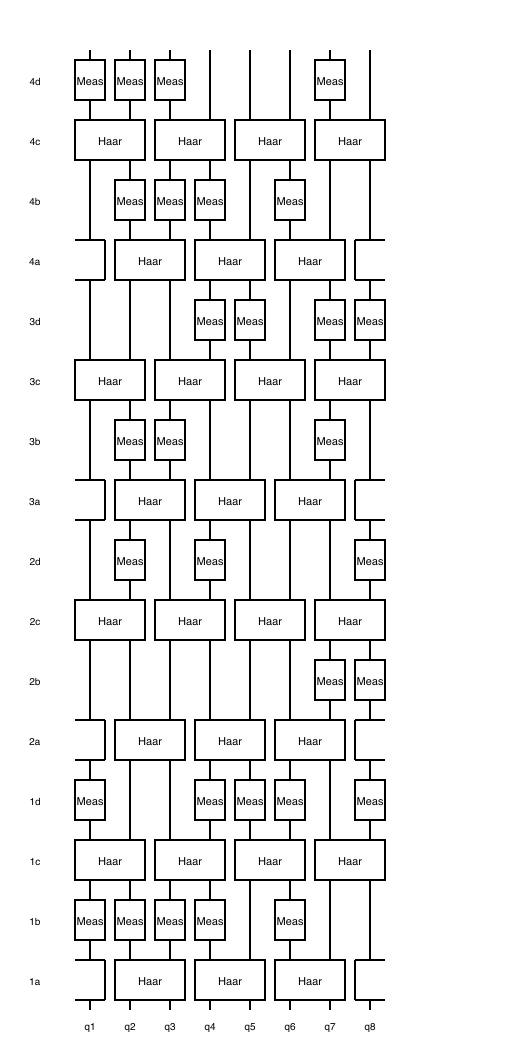

In [4]:
plot_circuit(circuit; gates_spacetime=0, n_steps=4)

## Section 3: Simulation with Entanglement Tracking

We track the **entanglement entropy** at the central cut (position L÷2) to monitor the competition between:
- Unitary entanglement generation
- Measurement-induced disentanglement

The `EntanglementEntropy` observable computes the von Neumann entropy across a bipartite cut:

$$S = -\sum_i \lambda_i^2 \log(\lambda_i^2)$$

where $\lambda_i$ are the Schmidt coefficients from the SVD of the MPS bond.

In [5]:
# Create simulation state with RNG registry
state = SimulationState(
    L=L,
    bc=bc,
    maxdim=64,
    rng=RNGRegistry(gates_spacetime=0, born_measurement=0, gates_realization=2)
)

# Initialize to product state |0⟩⊗L
initialize!(state, ProductState(binary_int=0))

# Track entanglement entropy at the central cut
track!(state, :entropy => EntanglementEntropy(; cut=cut))

# Run simulation: execute circuit n_steps times (n_steps=n_steps)
simulate!(circuit, state; n_steps=n_steps, record_when=:every_step)

# Extract entropy values from state
entropy_vals = state.observables[:entropy]

println("✓ Simulation complete")
println("  Recorded $(length(entropy_vals)) entropy values")
println()

✓ Simulation complete
  Recorded 8 entropy values

  Recorded 8 entropy values



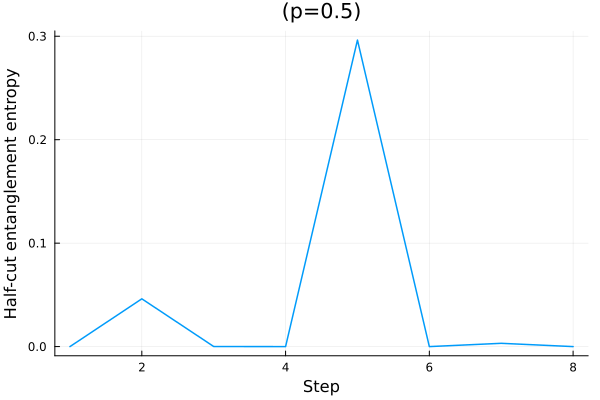

In [6]:
plot(entropy_vals, xlabel="Step", ylabel="Half-cut entanglement entropy", title="(p=$p)",
     legend=false, lw=1.5)

## Section 4: Steady-State Entanglement Entropy

Sweep `p` to compute the half-cut entanglement entropy as a function of measurement probability for multiple system sizes.

Each point is averaged over `ensemble_size` random seeds.

In [29]:
function run_mipt(; L, p, seed, bc=:periodic, n_steps=2*L, maxdim=2^20)
    circuit = Circuit(L=L, bc=bc, p=p) do c
        apply!(c, HaarRandom(), Bricklayer(:even))
        apply_with_prob!(c; outcomes=[
            (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
        ])
        apply!(c, HaarRandom(), Bricklayer(:odd))
        apply_with_prob!(c; outcomes=[
            (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
        ])
    end

    state = SimulationState(L=L, bc=bc, maxdim=maxdim,cutoff = 1e-10,
        # non-overlapping streams across trajectories
        rng=RNGRegistry(gates_spacetime=3*(seed-1)+1, born_measurement=3*(seed-1)+2, gates_realization=3*(seed-1)+3))
    initialize!(state, ProductState(binary_int=0))
    track!(state, :entropy => EntanglementEntropy(; cut=L÷2))

    simulate!(circuit, state; n_steps=n_steps, record_when=:final_only)
    return state.observables[:entropy][end]
end

run_mipt (generic function with 1 method)

In [30]:
# Sweep parameters
L_list = [6, 8, 10, 12, ]
# p_list = 0.1:0.1:0.9 |> collect
p_list = [0,0.1,.2,.3,.4,.5]
ensemble_size = 25  # reduced for quick notebook execution (recommended: 2000)

configs = [(L=L, p=p, seed=s) for L in L_list for p in p_list for s in 1:ensemble_size]
raw = Vector{Float64}(undef, length(configs))

# Run with `julia -t auto` for multithreaded execution
println("Running $(length(configs)) configs on $(Threads.nthreads()) threads...")
@time @showprogress Threads.@threads for i in eachindex(configs)
    c = configs[i]
    raw[i] = run_mipt(L=c.L, p=c.p, seed=c.seed)
end

# Reshape to (seed, p, L) and average over seeds
ns, np, nL = ensemble_size, length(p_list), length(L_list)
S_raw = reshape(raw, ns, np, nL)
S_mean = dropdims(mean(S_raw, dims=1), dims=1)
S_sem  = dropdims(std(S_raw, dims=1), dims=1) ./ sqrt(size(S_raw, 1))

println("Done!")

Running 600 configs on 4 threads...


Progress:   6%|██▌                                      |  ETA: 0:00:13

Progress: 100%|█████████████████████████████████████████| Time: 0:01:26


 86.612696 seconds (1.06 G allocations: 270.009 GiB, 15.63% gc time, 53 lock conflicts, 0.11% compilation time)
Done!


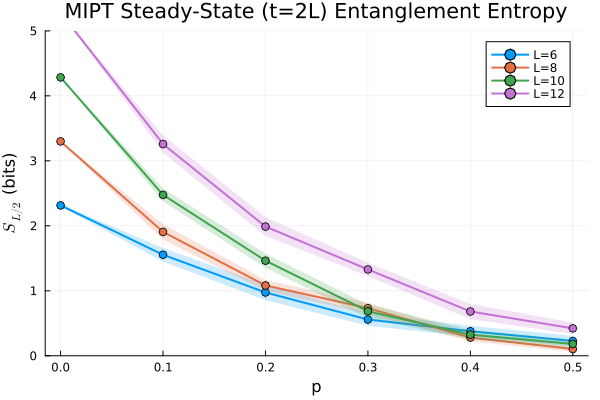

In [31]:
p_fig = plot(xlabel="p", ylabel=raw"$S_{L/2}$ (bits)", title=raw"MIPT Steady-State (t=2L) Entanglement Entropy", legend=:topright)
for (iL, L) in enumerate(L_list)
    plot!(p_fig, p_list, S_mean[:, iL], ribbon=S_sem[:, iL], fillalpha=0.2,
          label="L=$L", lw=2, marker=:o, ms=4, ylims=(0,5))
end
p_fig

## Section 5: SRN Boundary-Eligibility Protocol (Skinner–Ruhman–Nahum)

Skinner, Ruhman & Nahum, *PRX* **9**, 031009 (2019) [arXiv:1808.05953] use **open
boundary conditions (OBC)** with a specific measurement-eligibility rule: after
the even-bond Haar layer, only the **bulk** sites (2 through L-1) get a
measurement coin, since the edge sites (1 and L) did not just participate in a
fresh bond in that sublayer under OBC. After the odd-bond Haar layer, **every**
site gets a measurement coin. This "boundary eligibility" convention avoids the
$L \bmod 4$ parity artifact noted above (which comes from PBC's folded-basis
cut convention), and lets us reproduce their Fig. 13(a) volume-law/area-law
phase diagram quantitatively.

`run_mipt_srn` below builds this protocol as **one** `Circuit` with **two**
`record!(c)` markers (no manual `record!(state)` calls, no workaround scripts):

- Half-step A: `Bricklayer(:even)` Haar layer → `Measure(:Z)` with probability
  `p` on `EachSite(2:L-1)` (bulk-only) → `record!(c)`
- Half-step B: `Bricklayer(:odd)` Haar layer → `Measure(:Z)` with probability
  `p` on `AllSites()` → `record!(c)`
- `simulate!(circuit, state; n_steps=n_periods, record_when=:marks)` fires
  exactly at the two markers per period, deterministically.
- The half-cut bond $(L/2, L/2+1)$ is refreshed by the `:even` sublayer when
  $L/2$ is even and by the `:odd` sublayer when $L/2$ is odd, so we take the
  "fresh" snapshot (half-step A's record or half-step B's record,
  respectively) and average over the **last 4 periods** (steady state).

In [22]:
function run_mipt_srn(; L, p, seed, n_periods=4L, maxdim=2^20, cutoff=1e-10)
    iseven(L) || throw(ArgumentError("run_mipt_srn requires even L (got L=$L)"))

    circuit = Circuit(L=L, bc=:open, p=p) do c
        # Half-step A: even Haar bricklayer (bulk-only under OBC), then
        # bulk-only measurement coins (EachSite(2:L-1)).
        apply!(c, HaarRandom(), Bricklayer(:even))
        apply_with_prob!(c; outcomes=[
            (probability=c.params[:p], gate=Measure(:Z), geometry=EachSite(2:L-1))
        ])
        record!(c)

        # Half-step B: odd Haar bricklayer (touches all sites under OBC),
        # then all-site measurement coins (AllSites()).
        apply!(c, HaarRandom(), Bricklayer(:odd))
        apply_with_prob!(c; outcomes=[
            (probability=c.params[:p], gate=Measure(:Z), geometry=AllSites())
        ])
        record!(c)
    end

    state = SimulationState(L=L, bc=:open, maxdim=maxdim, cutoff=cutoff,
        rng=RNGRegistry(gates_spacetime=3*(seed-1)+1, born_measurement=3*(seed-1)+2, gates_realization=3*(seed-1)+3))
    initialize!(state, ProductState(binary_int=0))
    track!(state, :entropy => EntanglementEntropy(; cut=L÷2))

    # record_when=:marks fires EXACTLY at the two record!(c) markers above.
    simulate!(circuit, state; n_steps=n_periods, record_when=:marks)

    records = state.observables[:entropy]  # length 2*n_periods: [A1,B1,A2,B2,...]
    fresh_phase = iseven(L ÷ 2) ? 1 : 2     # 1 = half-step A (:even), 2 = half-step B (:odd)
    tail = records[end-7:end]               # last 4 periods = last 8 records
    return fresh_phase == 1 ? mean(tail[1:2:end]) : mean(tail[2:2:end])
end


run_mipt_srn (generic function with 1 method)

In [33]:
# Sweep parameters
L_list = [6, 8, 10, 12,]
# p_list = 0.1:0.1:0.9 |> collect
p_list = [0,0.1,.2,.3,.4,.5]
ensemble_size = 25  # reduced for quick notebook execution (recommended: 2000)

configs = [(L=L, p=p, seed=s) for L in L_list for p in p_list for s in 1:ensemble_size]
raw = Vector{Float64}(undef, length(configs))

# Run with `julia -t auto` for multithreaded execution
println("Running $(length(configs)) configs on $(Threads.nthreads()) threads...")
@time @showprogress Threads.@threads for i in eachindex(configs)
    c = configs[i]
    raw[i] = run_mipt_srn(L=c.L, p=c.p, seed=c.seed)
end

# Reshape to (seed, p, L) and average over seeds
ns, np, nL = ensemble_size, length(p_list), length(L_list)
S_raw = reshape(raw, ns, np, nL)
S_mean = dropdims(mean(S_raw, dims=1), dims=1)
S_sem  = dropdims(std(S_raw, dims=1), dims=1) ./ sqrt(size(S_raw, 1))

println("Done!")

Running 600 configs on 4 threads...


Progress: 100%|█████████████████████████████████████████| Time: 0:02:18


138.074744 seconds (1.91 G allocations: 464.542 GiB, 17.38% gc time, 53 lock conflicts, 0.04% compilation time)
Done!


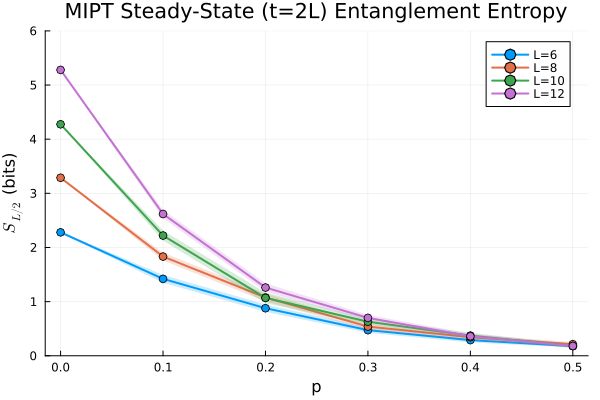

In [35]:
p_fig = plot(xlabel="p", ylabel=raw"$S_{L/2}$ (bits)", title=raw"MIPT Steady-State (t=2L) Entanglement Entropy", legend=:topright)
for (iL, L) in enumerate(L_list)
    plot!(p_fig, p_list, S_mean[:, iL], ribbon=S_sem[:, iL], fillalpha=0.2,
          label="L=$L", lw=2, marker=:o, ms=4, ylims=(0,6))
end
p_fig